In [1]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
import fem_pendulum

In [2]:
model = fem_pendulum.FEMPendulum(name="Pendulum", group="Plant")

model._with_contact= False
model._use_gravity = False

model.init_params.angular_position_deg = 0
model.init_params.angular_velocity = 0
model.init_params.angular_acceleration = 0

model.initialize(0.0)
#model.visualize_state()
model.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
t = 0.0
dt = 0.01
t_end = 1.0
torque_vals = []
alpha_vals = []
omega_vals = []
theta_vals = []

torque = 1

while t < t_end:
    if t < 0.25 * t_end:
        model.set_inputs({'torque':torque}, t)
    elif t > 0.25 * t_end and t < 0.75 * t_end:
        model.set_inputs({'torque':-torque}, t)
    else:
        model.set_inputs({'torque':torque}, t)
    model.do_step(t, dt)
    torque_vals.append(model.inputs['torque'].get())
    alpha_vals.append(model.outputs['alpha'].get())
    omega_vals.append(model.outputs['omega'].get())
    theta_vals.append(model.outputs['q'].get())
    t += dt

In [8]:
t_vals, theta_vals = zip(*model.outputs['q'].history)

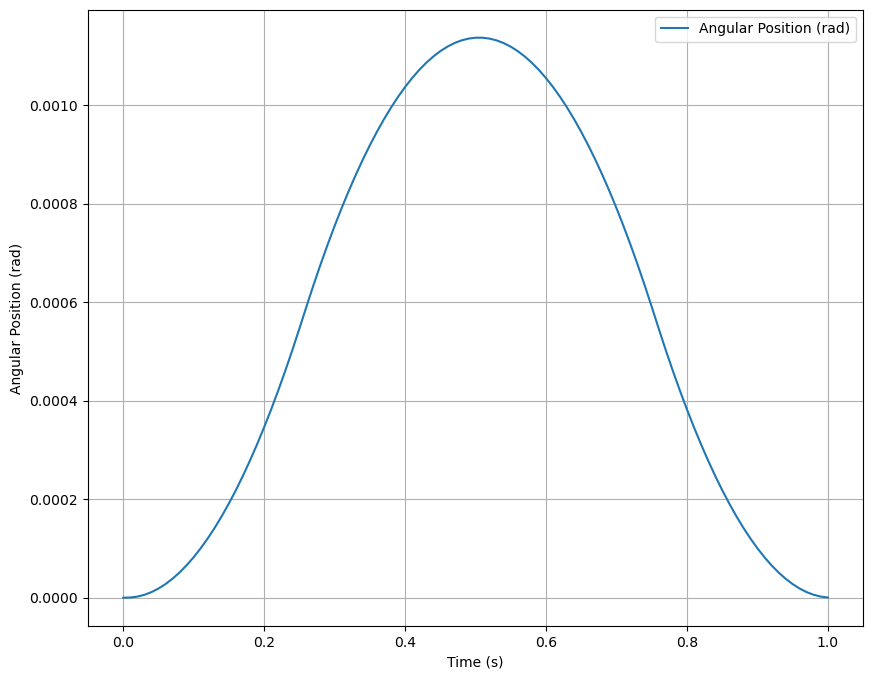

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.plot(t_vals, theta_vals, label='Angular Position (rad)')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.grid()
plt.legend()
plt.show()


In [6]:
import numpy as np

print(f"Final Angle (deg): {np.rad2deg(model.outputs['q'].get())}")

Final Angle (deg): 2.6177971522641917×10⁻⁵ deg


---------------------

In [7]:
model2 = fem_penduluml.FEMPendulum(name="PendulumWithContact", group="Plant")
model2._with_contact = True
model2._use_gravity = True

model2.init_params.angular_position_deg = 20.0
model2.initialize(0.0)
model2.visualize_state()

NameError: name 'fem_penduluml' is not defined

In [ ]:
model2.setup_simulation_diagnostics()

In [ ]:
model2.do_step(0, 1)

In [ ]:
t_vals, q_vals = zip(*model2.outputs['q'].history)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(t_vals, q_vals)
plt.xlabel('Time [s]')
plt.ylabel('Angular Position [rad]')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8, label="Wall Position")
plt.axhline(q_vals[0], color='r', linestyle='--', linewidth=0.8, label='Initial Position')
plt.grid()
plt.legend(loc="lower right")
plt.show()